In [22]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np

In [23]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [24]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [25]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
   subset['label'] = subset['label'].astype(str)



In [5]:
# === 2. Sauvegarde des DataFrames en CSV pour traçabilité future ===
train_df.to_csv(os.path.join(SAVE_DIR, 'train_labels.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR, 'val_labels.csv'), index=False)
test_df.to_csv(os.path.join(SAVE_DIR, 'test_labels.csv'), index=False)

# === 3. Copie physique des images ===
def save_images_from_df(df, subset_name):
    subset_dir = os.path.join(SAVE_DIR, subset_name)
    os.makedirs(subset_dir, exist_ok=True)
    
    for _, row in df.iterrows():
        image_filename = row['image_id']  # ou 'image' si c'est la colonne dans ton CSV
        possible_extensions = ['.jpg', '.jpeg', '.png']
        
        # Trouver le fichier existant avec une des extensions
        for ext in possible_extensions:
            test_path = os.path.join(DATASET_DIR, image_filename + ext)
            if os.path.exists(test_path):
                src_path = test_path
                break
        else:
            print(f"[⚠️] Image introuvable : {image_filename}")
            continue

        class_dir = os.path.join(subset_dir, row['label'])
        os.makedirs(class_dir, exist_ok=True)
        dst_path = os.path.join(class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)


save_images_from_df(train_df, 'train')
save_images_from_df(val_df, 'val')
save_images_from_df(test_df, 'test')


KeyboardInterrupt: 

In [5]:
def print_class_distribution(df, name="Dataset"):
    print(f"\n📊 Répartition dans {name} :")
    dist = df['label'].value_counts().sort_index()
    for i, count in dist.items():
        print(f"{CLASS_LABELS[int(i)]:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test")


📊 Répartition dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition dans Test :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112


In [26]:
# Facteurs de sampling (uniquement pour train)
sampling_factors = {
    0: 1,    # akiec
    1: 1,     # bcc
    2: 1,   # bkl
    3: 8,    # df
    4: 1,  # nv
    5: 1,    # vasc
    6: 6    # mel
}

# Vérification des répartitions
def print_class_distribution(df, name="Dataset"):
    dist = df['label'].value_counts().sort_index()
    print(f"\n📊 Répartition des classes dans {name} :")
    for i, count in dist.items():
        class_name = CLASS_LABELS[int(i)]
        print(f"{class_name:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test Interne")

def resample_dataframe(df, factors):
    resampled_df = []

    for label, factor in factors.items():
        subset = df[df['label'] == str(label)]
        n_samples = int(len(subset) * factor)

        if factor > 1:
            duplicated = pd.concat([subset] * int(factor), ignore_index=True)
            remainder = int((factor % 1) * len(subset))
            if remainder > 0:
                duplicated = pd.concat([duplicated, subset.sample(n=remainder, replace=True, random_state=42)], ignore_index=True)
        elif factor < 1:
            duplicated = subset.sample(n=n_samples, random_state=42)
        else:
            duplicated = subset

        resampled_df.append(duplicated)

    return pd.concat(resampled_df, ignore_index=True).sample(frac=1, random_state=42)

# ➕ Application du resampling uniquement sur le train
train_df_balanced = resample_dataframe(train_df, sampling_factors)

# 🔍 Vérification finale
print_class_distribution(train_df_balanced, "Train (Resampled)")



📊 Répartition des classes dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition des classes dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition des classes dans Test Interne :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112

📊 Répartition des classes dans Train (Resampled) :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 736
nv     : 5364
vasc   : 114
mel    : 5340


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications.densenet import preprocess_input


# Définition des classes rares (indices int)
RARE_CLASSES = [0, 3, 5, 6]  # akiec, df, vasc, mel

# Séparation des dataframes en classes rares et communes
df_rare = train_df_balanced[train_df_balanced['label'].astype(int).isin(RARE_CLASSES)]
df_common = train_df_balanced[~train_df_balanced['label'].astype(int).isin(RARE_CLASSES)]

# Liste complète des classes en str (pour forcer la même encodage one-hot)
all_classes = sorted(train_df['label'].astype(str).unique())


# Augmentation douce pour classes communes
common_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=35,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.05,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=10.0,

)

# Augmentation forte pour classes rares
rare_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=60,                # rotations réalistes sans tout retourner
    zoom_range=[0.8, 1.2],                   # léger zoom in/out
    width_shift_range=0.15,          # petits déplacements
    height_shift_range=0.15,
    horizontal_flip=True,            # miroir ok
    vertical_flip=False,             # généralement pas réaliste en dermato
    shear_range=0.1,                  # légère déformation
    brightness_range=[0.80, 1.2],   # variations douces d’éclairage
    channel_shift_range=10.0,        # petit ajustement des couleurs
    fill_mode='reflect',
 
)

# Générateurs pour classes communes et rares avec classes fixes
common_gen = common_aug.flow_from_dataframe(
    df_common,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
    dtype='float32'
)

rare_gen = rare_aug.flow_from_dataframe(
    df_rare,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
    dtype='float32'
)

# Générateur combiné avec batch_size constant
class CombinedGenerator(Sequence):
    def __init__(self, gen1, gen2, batch_size):
        self.gen1 = gen1
        self.gen2 = gen2
        self.batch_size = batch_size
        self.half_batch = batch_size // 2

    def __len__(self):
        return max(len(self.gen1), len(self.gen2))

    def __getitem__(self, index):
        x1, y1 = self.gen1[index % len(self.gen1)]
        x2, y2 = self.gen2[index % len(self.gen2)]

        # Sous-échantillonnage si batch trop grand
        if x1.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x1.shape[0]))[:self.half_batch]
            x1, y1 = tf.gather(x1, idx), tf.gather(y1, idx)

        if x2.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x2.shape[0]))[:self.half_batch]
            x2, y2 = tf.gather(x2, idx), tf.gather(y2, idx)

        x = tf.concat([x1, x2], axis=0)
        y = tf.concat([y1, y2], axis=0)
        return x, y

# Instanciation du générateur combiné
train_generator = CombinedGenerator(common_gen, rare_gen, batch_size=32)

# Accès au premier batch (correct pour Sequence)
images, labels = train_generator[0]

# Affichage min et max avec tf.reduce_min/max et numpy()
images_min = tf.reduce_min(images).numpy()
images_max = tf.reduce_max(images).numpy()

print(f"Nouvelle plage des pixels : {images_min} {images_max}")
print(f"Taille du batch images : {images.shape}, labels : {labels.shape}")


Found 6654 validated image filenames belonging to 7 classes.
Found 2694 validated image filenames belonging to 7 classes.
Nouvelle plage des pixels : -2.1179039478302 2.640000104904175
Taille du batch images : (32, 224, 224, 3), labels : (32, 7)


2025-08-14 09:14:56.673268: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-08-14 09:14:56.673319: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-08-14 09:14:56.673323: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1755155696.673603   19650 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1755155696.673869   19650 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
# Liste complète des classes en str (pour forcer la même encodage one-hot)
all_classes = sorted(train_df['label'].astype(str).unique())

from tensorflow.keras.preprocessing.image import ImageDataGenerator
# --- 🔍 Pas d'augmentation pour validation / test ---
val_test_datagen = ImageDataGenerator(
          preprocessing_function=preprocess_input 
)
# --- 🎯 Validation generator ---
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=all_classes
)

# --- 🧪 Test generator ---
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=all_classes
)

Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [8]:
# Récupère un batch depuis le générateur de validation ou test
images, labels = val_generator[0]  # ou test_generator[0]

# Vérifie la plage des pixels
import tensorflow as tf

min_val = tf.reduce_min(images).numpy()
max_val = tf.reduce_max(images).numpy()

print(f"Plage des valeurs de pixels après preprocessing : {min_val:.4f} à {max_val:.4f}")
print(f"Taille du batch : {images.shape}, Labels : {labels.shape}")


Plage des valeurs de pixels après preprocessing : -2.1179 à 2.6400
Taille du batch : (32, 224, 224, 3), Labels : (32, 7)


In [7]:
import tensorflow as tf
x_val, y_val = val_generator[0]
print(tf.reduce_min(x_val).numpy(), tf.reduce_max(x_val).numpy())  # devrait donner -1.0 / 1.0
print(x_val.shape, y_val.shape)  # (BATCH_SIZE, 300, 300, 3), (BATCH_SIZE, 7)

-2.117904 2.64
(32, 224, 224, 3) (32, 7)


2025-07-09 14:04:48.089794: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-09 14:04:48.089838: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-09 14:04:48.089841: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1752062688.089890  383070 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1752062688.089946  383070 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [27]:
# 🔁 Conversion des labels en string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)
train_df_balanced['label'] = train_df_balanced['label'].astype(str)

In [28]:
class_names = sorted(train_df['label'].unique().tolist())

In [9]:
from tensorflow.keras.applications.densenet import preprocess_input
import tensorflow as tf
import tensorflow_probability as tfp

# ---- TargetedAugmentDataset ----
class TargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.strong_aug_classes = tf.constant(['mel', 'bkl', 'df', 'akiec'], dtype=tf.string)

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            img = tf.cond(
                tf.reduce_any(tf.equal(tf.expand_dims(label, axis=0), self.strong_aug_classes)),
                lambda: self.strong_augmentation(img),
                lambda: self.standard_augmentation(img)
            )

        # Normalisation spécifique DenseNet
        img = preprocess_input(img)
        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.resize_with_crop_or_pad(img, new_size[0], new_size[1])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = tf.cast(tf.random.uniform((), 0.1, 0.3) * tf.cast(self.img_size[0], tf.float32), tf.int32)
            img = self.apply_cutout(img, mask_size)

        if tf.random.uniform(()) > 0.5:
            img = tf.image.random_hue(img, 0.05)

        if tf.random.uniform(()) > 0.5:
            scales = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
            new_size = tf.cast(scales * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.resize(img, new_size)
            img = tf.image.random_crop(img, size=[self.img_size[0], self.img_size[1], 3])

        if tf.random.uniform(()) > 0.7:
            small = tf.image.resize(img, [self.img_size[0] // 2, self.img_size[1] // 2])
            img = tf.image.resize(small, self.img_size)

        if tf.random.uniform(()) > 0.9:
            img = 255.0 - img

        return tf.clip_by_value(img, 0.0, 255.0)

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        if tf.random.uniform(()) > 0.5:
            img = tf.image.random_hue(img, 0.03)
        return tf.clip_by_value(img, 0.0, 255.0)

    def apply_cutout(self, img, size):
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        mask = tf.ones([h, w], dtype=tf.float32)
        mask = tf.tensor_scatter_nd_update(
            mask,
            indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing='ij'), axis=-1), (-1, 2)),
            updates=tf.zeros((y2 - y1) * (x2 - x1))
        )
        mask = tf.expand_dims(mask, axis=-1)
        mask = tf.tile(mask, [1, 1, 3])

        return img * mask



In [29]:
import tensorflow as tf
import tensorflow_probability as tfp

def mixup_or_cutmix(dataset, class_names, rare_classes=['mel', 'akiec', 'bkl', 'df'], alpha=0.3, prob_mixup=0.5, prob_cutmix=0.5):
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        apply_mix = tf.reduce_any(is_rare)

        def no_mix():
            return tf.cast(images, tf.float32), labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)

            lam = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
            lam = tf.maximum(lam, 1. - lam)
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            def do_mixup():
                mixed_images = lam_img * tf.cast(images, tf.float32) + (1. - lam_img) * tf.cast(shuffled_images, tf.float32)
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                return mixed_images, mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                x1 = tf.clip_by_value(cx - cut_w // 2, 0, img_w)
                y1 = tf.clip_by_value(cy - cut_h // 2, 0, img_h)
                x2 = tf.clip_by_value(cx + cut_w // 2, 0, img_w)
                y2 = tf.clip_by_value(cy + cut_h // 2, 0, img_h)

                def cutmix_single(i):
                    image = tf.cast(images[i], tf.float32)
                    shuffled = tf.cast(shuffled_images[i], tf.float32)
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = x1[i]
                    yi1 = y1[i]
                    xi2 = x2[i]
                    yi2 = y2[i]

                    mask = tf.ones_like(image, dtype=tf.float32)
                    y_range = tf.range(yi1, yi2)
                    x_range = tf.range(xi1, xi2)
                    y_grid, x_grid = tf.meshgrid(y_range, x_range, indexing='ij')
                    coords = tf.stack([y_grid, x_grid], axis=-1)
                    coords_flat = tf.reshape(coords, [-1, 2])
                    updates = tf.zeros((tf.shape(coords_flat)[0], 3), dtype=tf.float32)
                    mask = tf.tensor_scatter_nd_update(mask, coords_flat, updates)

                    mixed_image = image * mask + shuffled * (1. - mask)
                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2

                    return mixed_image, mixed_label

                mixed_images, mixed_labels = tf.map_fn(
                    cutmix_single,
                    tf.range(batch_size),
                    fn_output_signature=(tf.float32, tf.float32)
                )
                return mixed_images, mixed_labels

            choice = tf.random.uniform([], 0, 1)
            return tf.cond(
                choice < prob_mixup,
                do_mixup,
                lambda: tf.cond(
                    choice < prob_mixup + prob_cutmix,
                    do_cutmix,
                    lambda: (tf.cast(images, tf.float32), labels)
                )
            )

        return tf.cond(apply_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


In [10]:
import tensorflow as tf
import tensorflow_probability as tfp

# 1. Définir la liste alpha par classe, adaptée à ta stratégie
alpha_list = [
    4.0,  # AKIEC (réduit de 16)
    2.0,  # BCC
    4.0,  # BKL
    5.0,  # DF (réduit de 20)
    0.9,  # NV
    2.0,  # VASC
    5.0   # MEL (réduit de 18)
]


import tensorflow as tf
import tensorflow_probability as tfp

def mixup_or_cutmix(dataset, class_names, alpha_list, rare_classes=['mel', 'akiec', 'bkl', 'df'], prob_mixup=0.5, prob_cutmix=0.5):
    # Indices des classes rares
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)
    alpha_tensor = tf.constant(alpha_list, dtype=tf.float32)

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        apply_mix = tf.reduce_any(is_rare)

        def no_mix():
            return tf.cast(images, tf.float32), labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)
            shuffled_labels_argmax = tf.argmax(shuffled_labels, axis=1, output_type=tf.int32)

            # Récupère alpha des classes de la paire (original & mélangée)
            alpha_orig = tf.gather(alpha_tensor, labels_argmax)
            alpha_shuf = tf.gather(alpha_tensor, shuffled_labels_argmax)
            # Moyenne des alpha des deux classes pour chaque exemple
            alpha_batch = (alpha_orig + alpha_shuf) / 2.0
            alpha_batch = tf.clip_by_value(alpha_batch, 0.1, 5.0)  # limite pour éviter trop grand alpha

            lam = tfp.distributions.Beta(alpha_batch, alpha_batch).sample()
            lam = tf.maximum(lam, 1. - lam)
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            def do_mixup():
                mixed_images = lam_img * tf.cast(images, tf.float32) + (1. - lam_img) * tf.cast(shuffled_images, tf.float32)
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                return mixed_images, mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                x1 = tf.clip_by_value(cx - cut_w // 2, 0, img_w)
                y1 = tf.clip_by_value(cy - cut_h // 2, 0, img_h)
                x2 = tf.clip_by_value(cx + cut_w // 2, 0, img_w)
                y2 = tf.clip_by_value(cy + cut_h // 2, 0, img_h)

                def cutmix_single(i):
                    image = tf.cast(images[i], tf.float32)
                    shuffled = tf.cast(shuffled_images[i], tf.float32)
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = x1[i]
                    yi1 = y1[i]
                    xi2 = x2[i]
                    yi2 = y2[i]

                    mask = tf.ones_like(image, dtype=tf.float32)
                    y_range = tf.range(yi1, yi2)
                    x_range = tf.range(xi1, xi2)
                    y_grid, x_grid = tf.meshgrid(y_range, x_range, indexing='ij')
                    coords = tf.stack([y_grid, x_grid], axis=-1)
                    coords_flat = tf.reshape(coords, [-1, 2])
                    updates = tf.zeros((tf.shape(coords_flat)[0], 3), dtype=tf.float32)
                    mask = tf.tensor_scatter_nd_update(mask, coords_flat, updates)

                    mixed_image = image * mask + shuffled * (1. - mask)
                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2

                    return mixed_image, mixed_label

                mixed_images, mixed_labels = tf.map_fn(
                    cutmix_single,
                    tf.range(batch_size),
                    fn_output_signature=(tf.float32, tf.float32)
                )
                return mixed_images, mixed_labels

            choice = tf.random.uniform([], 0, 1)
            return tf.cond(
                choice < prob_mixup,
                do_mixup,
                lambda: tf.cond(
                    choice < prob_mixup + prob_cutmix,
                    do_cutmix,
                    lambda: (tf.cast(images, tf.float32), labels)
                )
            )

        return tf.cond(apply_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


In [30]:
# Liste des classes (dans le bon ordre)
class_names = sorted(train_df['label'].unique().tolist())

augmenter = TargetedAugmentDataset(train_df_balanced, img_size=(224, 224), class_names=class_names, batch_size=32, augment=True)
train_ds = augmenter.get_dataset()


train_ds = mixup_or_cutmix(
    train_ds,
    class_names=class_names,
    rare_classes=['mel', 'akiec', 'bkl', 'df'],  # ou autre selon ton sampling
    alpha=0.1,
    prob_mixup=0.2,
    prob_cutmix=0.2
)


In [29]:
# Liste des classes (dans le bon ordre)
class_names = sorted(train_df['label'].unique().tolist())

# Ta liste d'alpha par classe (même ordre que class_names)
alpha_list = [
    4,   # akiec
    1.0,  # bcc
    1.0,  # bkl
    5.0, # df
    0.9,  # nv
    2.0,  # vasc
    5.0  # mel
]

augmenter = TargetedAugmentDataset(train_df_balanced, img_size=(224, 224), class_names=class_names, batch_size=32, augment=True)
train_ds = augmenter.get_dataset()

train_ds = mixup_or_cutmix(
    train_ds,
    class_names=class_names,
    alpha_list=alpha_list,  # <-- ici on passe la liste complète
    rare_classes=['mel', 'akiec', 'bkl', 'df'],  # à adapter selon ton sampling
    prob_mixup=0.2,
    prob_cutmix=0.3
)


TypeError: mixup_or_cutmix() got an unexpected keyword argument 'alpha_list'

In [17]:
val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=(224, 224),
    class_names=class_names,
    batch_size=32,
    augment=False
).get_dataset()

In [9]:
# Alpha Pondéré

import numpy as np
from collections import Counter
from tqdm import tqdm

class_counts = Counter()

# Assure-toi que train_generator is not infinite (no shuffle, no repeat)
for i in tqdm(range(len(train_generator))):
    _, y_batch = train_generator[i]
    labels = np.argmax(y_batch, axis=1)
    class_counts.update(labels)

# Affichage propre
print("\n==> Distribution par classe :")
for idx, count in class_counts.items():
    print(f"Classe {idx} ({CLASS_LABELS[idx]}): {count} images")

# Calcul alpha pondéré inversé
total = sum(class_counts.values())
alpha = [total / class_counts[i] for i in range(len(CLASS_LABELS))]
alpha = np.array(alpha)
alpha = alpha / np.sum(alpha)

print("\n==> Alpha pondéré (normalisé) :")
for idx, a in enumerate(alpha):
    print(f"{CLASS_LABELS[idx]} (classe {idx}) : {a:.4f}")


100%|██████████| 220/220 [00:55<00:00,  3.95it/s]


==> Distribution par classe :
Classe 4 (nv): 4693 images
Classe 2 (bkl): 769 images
Classe 0 (akiec): 229 images
Classe 1 (bcc): 360 images
Classe 6 (mel): 779 images
Classe 5 (vasc): 99 images
Classe 3 (df): 81 images

==> Alpha pondéré (normalisé) :
akiec (classe 0) : 0.1348
bcc (classe 1) : 0.0858
bkl (classe 2) : 0.0401
df (classe 3) : 0.3812
nv (classe 4) : 0.0066
vasc (classe 5) : 0.3119
mel (classe 6) : 0.0396


In [32]:
# Poids alpha spécifiques pour classes déséquilibrées
alpha = [
    1,  # AKIEC
    1,  # BCC
    1,  # BKL
    6.0,  # DF
    1,  # NV
    1,  # VASC
    7   # MEL
]

import tensorflow as tf

def focal_loss(alpha, gamma=1):
    alpha_tensor = tf.constant(alpha, dtype=tf.float32)  # Une seule fois

    @tf.function
    def loss(y_true, y_pred):
        # Cast en float32 pour éviter les erreurs en mixed precision
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Clipping pour éviter log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Probabilité prédite pour la bonne classe
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Cross-entropy simple
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Poids focal
        focal_weight = tf.pow(1.0 - p_t, gamma)

        # Alpha pondéré par classe (sélectionne le bon poids pour chaque exemple)
        alpha_t = tf.reduce_sum(alpha_tensor * y_true, axis=-1)

        # Focal loss
        loss = alpha_t * focal_weight * ce
        return tf.reduce_mean(loss)

    return loss


In [33]:
import tensorflow as tf
from tensorflow.keras import backend as K

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras import mixed_precision


# ⚙️ Politique de précision mixte
mixed_precision.set_global_policy('mixed_float16')



In [10]:
import tensorflow as tf

def focal_loss(alpha=None, gamma=2.0):
    if alpha is not None:
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    @tf.function
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Proba prédite pour la bonne classe
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Cross-entropy simple
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Poids focal
        focal_weight = tf.pow(1.0 - p_t, gamma)

        if alpha is not None:
            alpha_t = tf.reduce_sum(alpha_tensor * y_true, axis=-1)
        else:
            alpha_t = tf.ones_like(p_t)

        loss = alpha_t * focal_weight * ce
        return tf.reduce_mean(loss)

    return loss


In [17]:

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, layers, regularizers, mixed_precision
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, LearningRateScheduler
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import layers, Model, Input, optimizers, regularizers


# === 1. Politique Mixed Precision ===
mixed_precision.set_global_policy('mixed_float16')


# -----------------
# 2. Modèle avec Dropout paramétrable
# -----------------
from tensorflow.keras import layers, models, applications

def build_densenet201_ham(num_classes, dropout_rate=0.2, dropout_active=False):
    # Backbone DenseNet201
    backbone = applications.DenseNet201(
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    
    # Geler les BatchNorm (important en fine-tuning)
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # Entrée
    inputs = layers.Input(shape=(224, 224, 3))
    x = backbone(inputs, training=False)  # pas de BN update

    # Dropout si activé
    if dropout_active:
        x = layers.Dropout(dropout_rate)(x)

    # Dense intermédiaire
    x = layers.Dense(512, activation='relu')(x)

    # Dropout si activé
    if dropout_active:
        x = layers.Dropout(dropout_rate)(x)

    # Sortie
    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        dtype='float32'
    )(x)

    # Modèle final
    model = models.Model(inputs=inputs, outputs=outputs)
    return model


# Exemple Phase 1 : Dropout désactivé
N_CLASSES = 7
model = build_densenet201_ham(N_CLASSES, dropout_rate=0.2, dropout_active=False)


# === 4. Compilation ===
optimizer = optimizers.AdamW(learning_rate=1e-5, weight_decay=5e-4)
optimizer = mixed_precision.LossScaleOptimizer(optimizer)



In [18]:
model.compile(
    optimizer=optimizer,
    loss=focal_loss(alpha = alpha, gamma=2.),  # Focal loss personnalisée
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

In [34]:



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_AUC = 'Protocole-S-V2-Densenet201-DropOut7-valAUC.keras'
CHECKPOINT_ACC = 'Protocole-S-V2-Densenet201-DropOut7-valACC.keras'

callbacks = [
    # Early stopping sur val_auc (objectif principal)
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),

    # Sauvegarde du meilleur modèle basé sur val_auc
    ModelCheckpoint(
        filepath=CHECKPOINT_AUC,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Sauvegarde secondaire sur val_accuracy
    ModelCheckpoint(
        filepath=CHECKPOINT_ACC,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Réduction du learning rate sur stagnation du val_auc
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.9,
        patience=5,
        min_lr=1e-6,
        min_delta=1e-4,
        mode='max',
        verbose=1
    ),
]


In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5167 - auc: 0.8297 - loss: 1.9977 - precision: 0.6215 - recall: 0.3360
Epoch 1: val_auc improved from 0.50000 to 0.88832, saving model to Protocole-S-V2-Densenet201-DropOut-valAUC.keras

Epoch 1: val_accuracy improved from 0.00000 to 0.54645, saving model to Protocole-S-V2-Densenet201-DropOut-valACC.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.5939 - auc: 0.8858 - loss: 1.4248 - precision: 0.7008 - recall: 0.4426 - val_accuracy: 0.5465 - val_auc: 0.8883 - val_loss: 1.0493 - val_precision: 0.6576 - val_recall: 0.4835 - learning_rate: 1.0000e-05
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.6820 - auc: 0.9353 - loss: 0.8970 - precision: 0.7631 - recall: 0.5729
Epoch 2: val_auc improved from 0.88832 to 0.89529, saving model to Protocole-S-V2-Densenet201-DropOut-valAUC.keras

Epoch 2: val_accuracy improved from 0.54645 to 0.57942, saving model to Protocole-S-V2-Densenet201-DropOut-valACC

In [35]:
from tensorflow import keras
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, Model, Input, optimizers, regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import Dropout
from tensorflow.keras import layers, models, applications

from tensorflow import keras
from tensorflow.keras import mixed_precision, optimizers
from tensorflow.keras.metrics import Recall, Precision, AUC

LR = 1e-5
WEIGHT_DECAY = 5e-4
DROPOUT_RATE = 0.2
LABEL_SMOOTH = 0.07
NUM_CLASSES = 7

# 0. Politique de précision mixte
mixed_precision.set_global_policy('mixed_float16')

# 1. Configuration de l'optimiseur avec loss scaling
base_optimizer = optimizers.AdamW(
    learning_rate=3e-6,
    weight_decay=1e-5,  # Peut être ajusté si besoin
    global_clipnorm=1.0
)
optimizer = mixed_precision.LossScaleOptimizer(base_optimizer)

# === 1. Charger le modèle Phase 2 ===
model_phase2 = keras.models.load_model(
    'Protocole-S-V2-Densenet201-DropOut6-valAUC.keras',
    compile=False
)

# Essayer d’attraper le backbone DenseNet201
backbone = None
for layer in model_phase2.layers:
    if 'densenet' in layer.name.lower() or isinstance(layer, keras.Model):
        backbone = layer
        # Vérifie qu'il a beaucoup de sous-couches (DenseNet201 ~707)
        if hasattr(backbone, 'layers') and len(backbone.layers) > 100:
            break

if backbone is None:
    raise ValueError("Backbone DenseNet201 introuvable dans le modèle chargé.")

# ============================
# Débloquer TOUTES les couches (sauf BatchNorm)
# ============================
for l in backbone.layers:
    l.trainable = True
for l in backbone.layers:
    if isinstance(l, layers.BatchNormalization):
        l.trainable = False

# ============================
# Reconstruire le "top" avec Dropout actif
# ============================
inputs = model_phase2.input  # conserve l'entrée d’origine (224x224x3)
x = backbone(inputs, training=False)        # pas d’update BN
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(512, activation='swish')(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model_p4 = models.Model(inputs, outputs)

# === 5. Vérification ===
total_layers = sum(1 for _ in backbone.layers)
trainable_layers = sum(1 for l in backbone.layers if l.trainable)
print(f"Nombre total de sous-couches backbone : {total_layers}")
print(f"Nombre de sous-couches entraînables : {trainable_layers}")
        
# 4. Recompiler le modèle avec les bons paramètres
model_p4.compile(
    optimizer=optimizer,
    loss=focal_loss(alpha, gamma=2),
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

# 5. Vérification optionnelle
print(f"Nombre total de couches : {len(model_p4 .layers)}")
print(f"Nombre de couches gelées : {sum([not layer.trainable for layer in model_p4 .layers])}")



Nombre total de sous-couches backbone : 708
Nombre de sous-couches entraînables : 507
Nombre total de couches : 6
Nombre de couches gelées : 0


In [17]:
model = keras.models.load_model('Protocole-S-V2-Densenet201-Phase2-valAUC.keras', compile=False)
print(f"Nombre de couches dégelées à l'ouverture : {sum([layer.trainable for layer in model.layers])}")


Nombre de couches dégelées à l'ouverture : 225


In [18]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 0


In [18]:

# 3. Continuer l'entraînement
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    initial_epoch=1,
    callbacks=callbacks,
    verbose=1
)

NameError: name 'model' is not defined

In [36]:

# 3. Continuer l'entraînement
history = model_p4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    initial_epoch=0,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5909 - auc: 0.8331 - loss: 2.3852 - precision: 0.6850 - recall: 0.5043   
Epoch 1: val_auc improved from None to 0.97613, saving model to Protocole-S-V2-Densenet201-DropOut7-valAUC.keras

Epoch 1: val_accuracy improved from None to 0.82917, saving model to Protocole-S-V2-Densenet201-DropOut7-valACC.keras
410/410 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.7648 - auc: 0.9442 - loss: 0.9814 - precision: 0.8570 - recall: 0.7017 - val_accuracy: 0.8292 - val_auc: 0.9761 - val_loss: 0.5235 - val_precision: 0.8751 - val_recall: 0.7702 - learning_rate: 3.0000e-06
Epoch 2/100
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.9293 - auc: 0.9949 - loss: 0.1415 - precision: 0.9510 - recall: 0.9046
Epoch 2: val_auc improved from 0.97613 to 0.98112, saving model to Protocole-S-V2-Densenet201-DropOut7-valAUC.keras

Epoch 2: val_accuracy improved from 0.82917 to 0.87113, saving model to Protocole-S-V2-Densenet201-DropOut7-val

In [ ]:

# 3. Continuer l'entraînement
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=130,
    initial_epoch=59,
    callbacks=callbacks,
    verbose=1
)

Epoch 29/130
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7373 - auc: 0.9570 - loss: 0.0083 - precision: 0.8056 - recall: 0.6503
Epoch 29: val_auc improved from -inf to 0.95611, saving model to Protocole-S-Densenet201-valAUC.keras

Epoch 29: val_accuracy improved from -inf to 0.70439, saving model to Protocole-S-Densenet201-valACC.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 87s 349ms/step - accuracy: 0.7372 - auc: 0.9570 - loss: 0.0083 - precision: 0.8055 - recall: 0.6503 - val_accuracy: 0.7044 - val_auc: 0.9561 - val_loss: 0.0172 - val_precision: 0.7698 - val_recall: 0.6345 - learning_rate: 1.0000e-04
Epoch 30/130
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7285 - auc: 0.9574 - loss: 0.0084 - precision: 0.8081 - recall: 0.6508
Epoch 30: val_auc did not improve from 0.95611

Epoch 30: val_accuracy did not improve from 0.70439
220/220 ━━━━━━━━━━━━━━━━━━━━ 63s 285ms/step - accuracy: 0.7285 - auc: 0.9574 - loss: 0.0084 - precision: 0.8081 - recall: 0.6508 - val_accuracy: 0

In [ ]:
#Class Weight

CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))

class_weights[0] *= 3
class_weights[6] *= 3


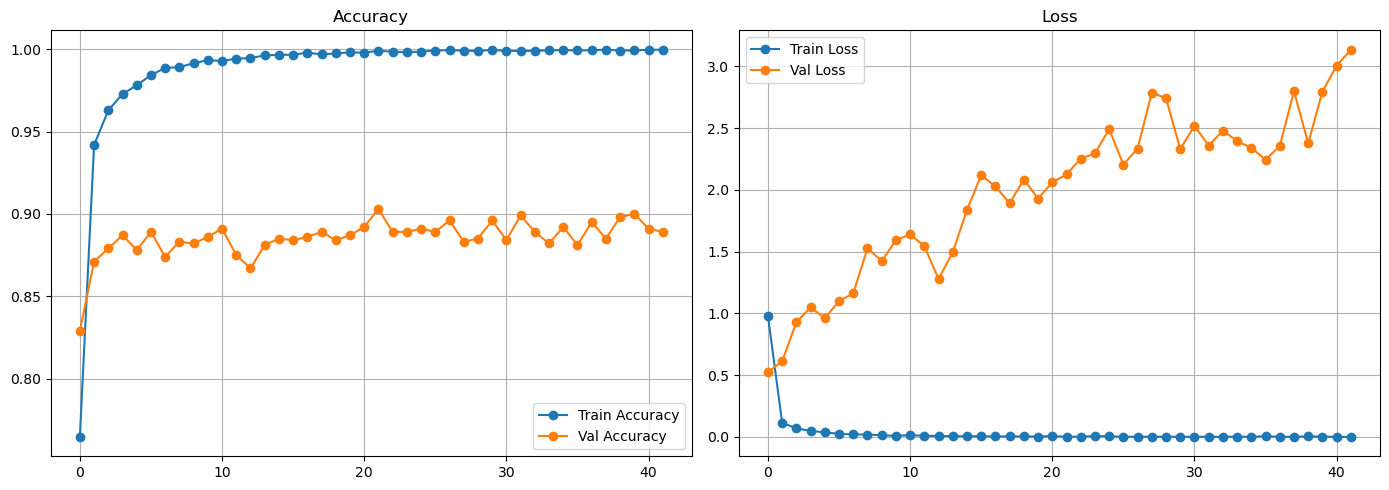

In [37]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

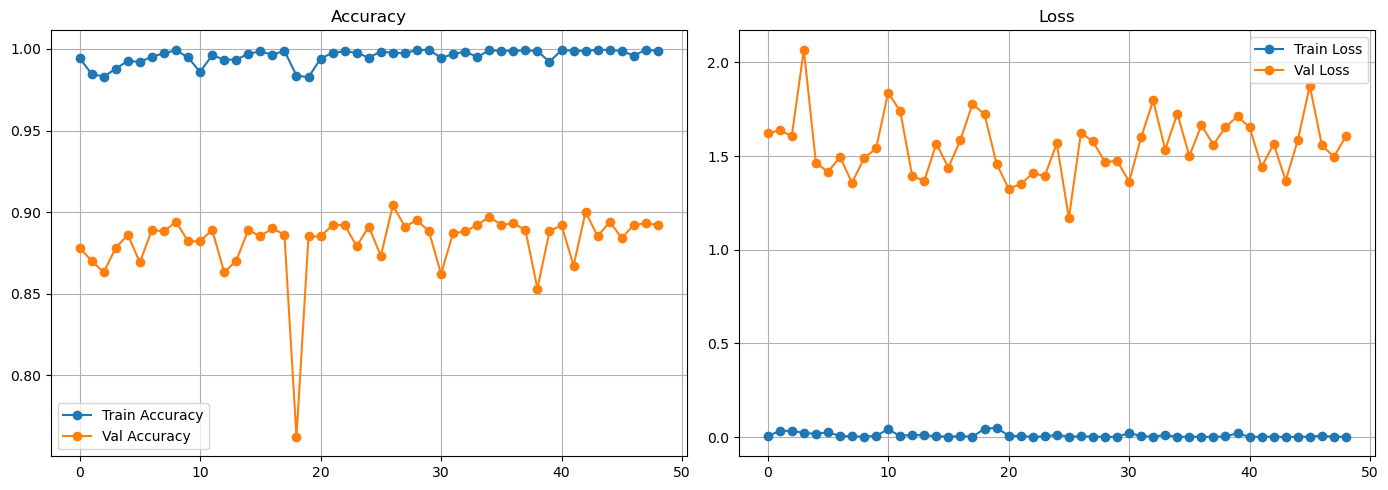

In [33]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 663ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1083/3776540589.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


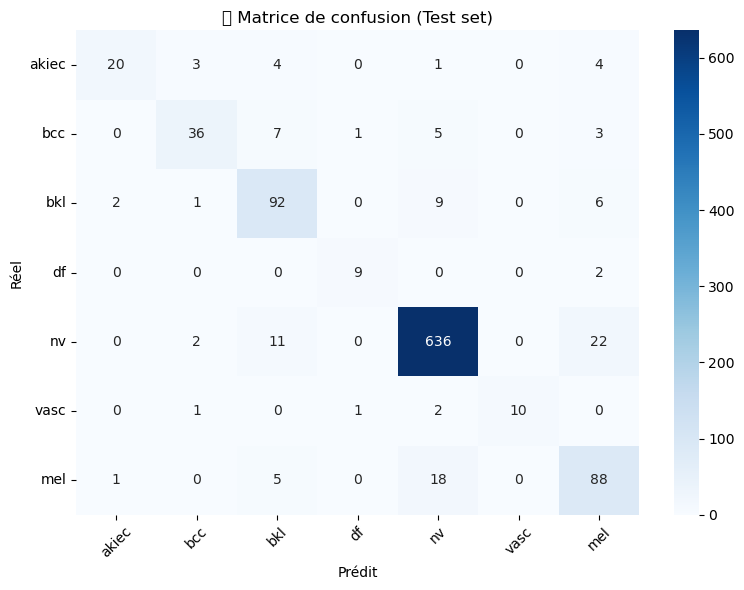


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.87      0.62      0.73        32
         bcc       0.84      0.69      0.76        52
         bkl       0.77      0.84      0.80       110
          df       0.82      0.82      0.82        11
          nv       0.95      0.95      0.95       671
        vasc       1.00      0.71      0.83        14
         mel       0.70      0.79      0.74       112

    accuracy                           0.89      1002
   macro avg       0.85      0.77      0.80      1002
weighted avg       0.89      0.89      0.89      1002



In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model_p4.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


In [27]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # history est ici un dictionnaire (pas un objet History)
    acc = history.get('accuracy', [])
    val_acc = history.get('val_accuracy', [])
    loss = history.get('loss', [])
    val_loss = history.get('val_loss', [])
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.axhline(y=0.85, color='gray', linestyle='--', label='Target')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    

    plt.tight_layout()
    plt.show()
    


plot_training_history(history)

AttributeError: 'History' object has no attribute 'get'

32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 833ms/step


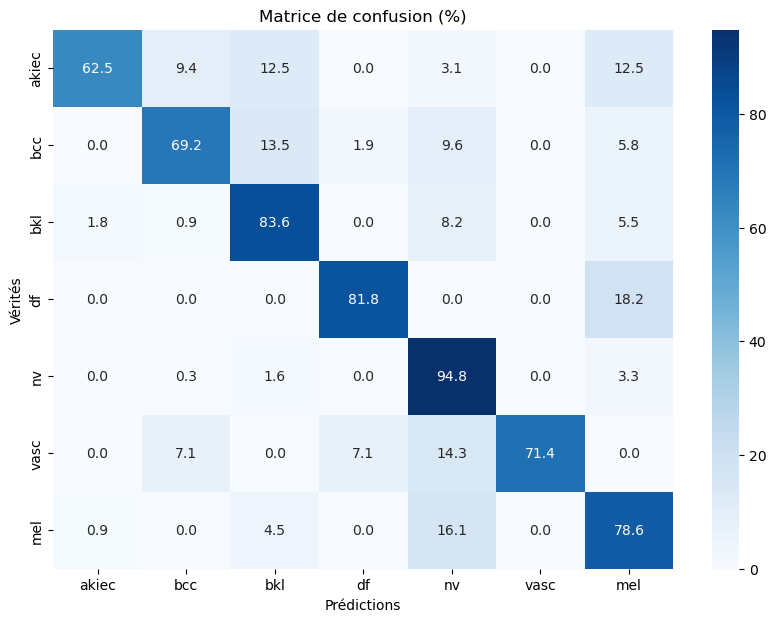

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model_p4.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 507ms/step


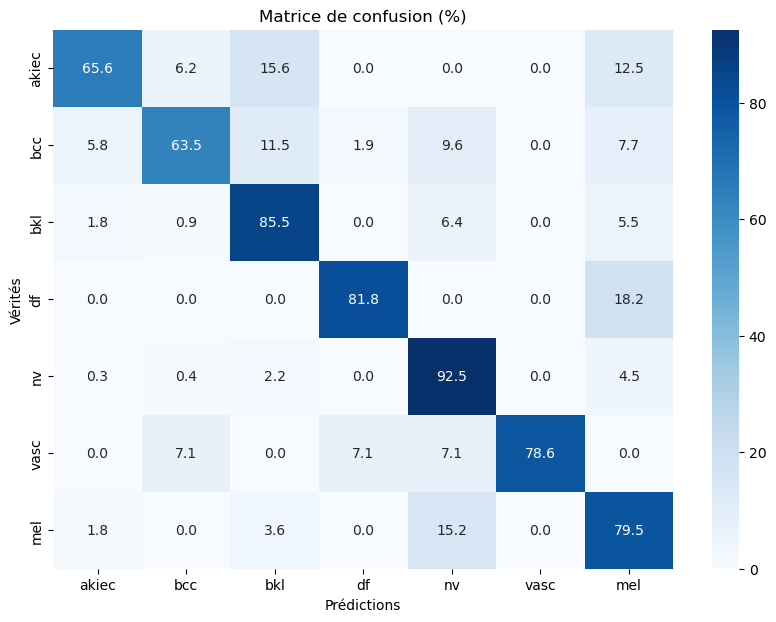

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 489ms/step


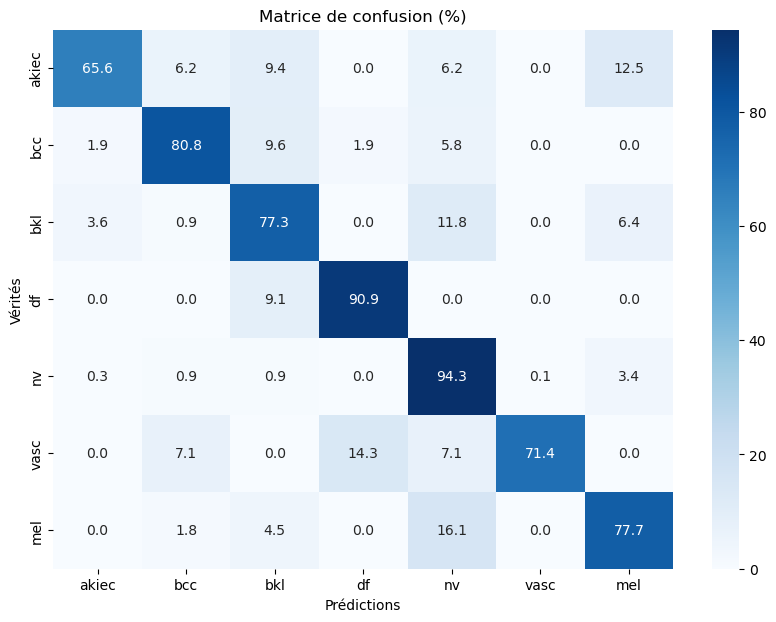

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step


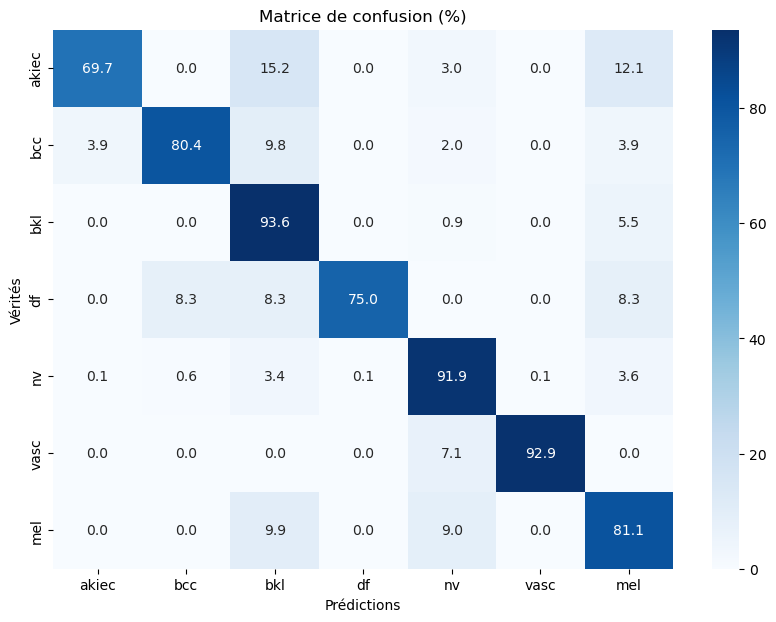

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 339ms/step


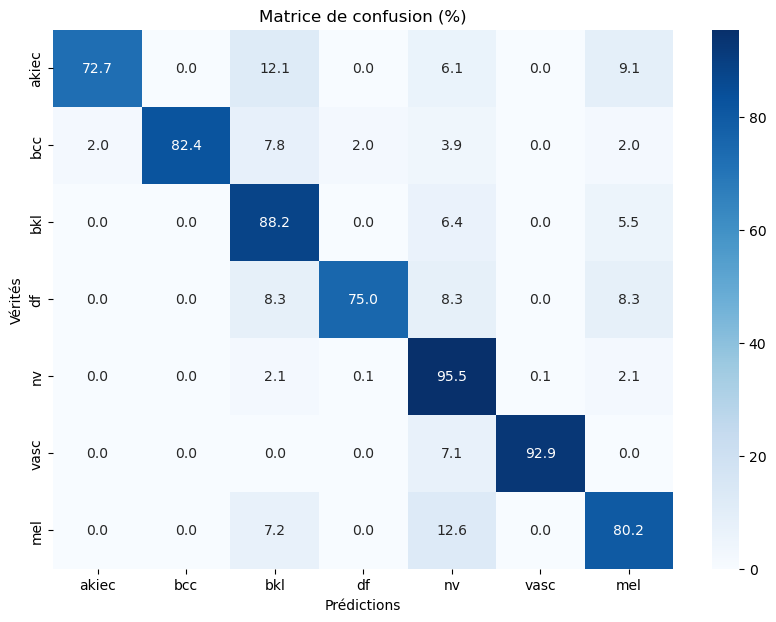

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()




In [21]:
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

@register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='attention_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True,
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = K.dot(inputs, self.attention_weights)
        weights = K.softmax(score, axis=1)
        context = weights * inputs
        return K.sum(context, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


2025-08-15 21:09:16.940184: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 470ms/step


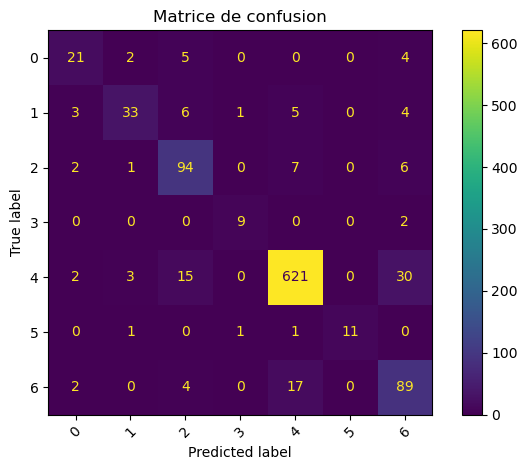

Rapport de classification :
              precision    recall  f1-score   support

           0       0.70      0.66      0.68        32
           1       0.82      0.63      0.72        52
           2       0.76      0.85      0.80       110
           3       0.82      0.82      0.82        11
           4       0.95      0.93      0.94       671
           5       1.00      0.79      0.88        14
           6       0.66      0.79      0.72       112

    accuracy                           0.88      1002
   macro avg       0.82      0.78      0.79      1002
weighted avg       0.88      0.88      0.88      1002



In [7]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input
#from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (224, 224)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Densenet201-DropOut6-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))
